#This notebook focuses on CUSUM method for deforestation analysis

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import rasterio

In [2]:
from google.colab import  drive
drive.mount('/content/drive')

Mounted at /content/drive


Inorder to check the TS working, first just take only the average mean of NDVI/VH for entire study area per date. This helps us to verify time series make sense visually by plotting the NDVI and VH over time and look for patterns.

### So first step is confirming fusion is working before pixel level analysis.

In [3]:
s2_final = "/content/drive/MyDrive/Deforestation_Project/data/S2/processed/s2_final"
s1_final = "/content/drive/MyDrive/Deforestation_Project/data/S1/processed/final"

In [7]:
s1_trial = []
for s1 in os.listdir(s1_final):
  if s1.endswith(".tif"):
    date_s1 = s1[24:32]
    with rasterio.open(os.path.join(s1_final, s1)) as src1:
      print(f'Starting trial VH for {date_s1}')
      vh_s1 = src1.read(1)
      mean_vh = np.nanmean(vh_s1)
      s1_trial.append({'date': date_s1, 'vh_db': mean_vh})
      print(f'{date_s1} finished')
print('s1 finished')

s2_trial = []
for s2 in os.listdir(s2_final):
  if s2.endswith(".tif"):
    date_s2 = s2[0:8]
    with rasterio.open(os.path.join(s2_final, s2)) as src2:
      print(f'Starting trial NDVI for {s2}')
      ndvi_s2 = src2.read(1)
      mean_ndvi = np.nanmean(ndvi_s2)
      s2_trial.append({'date': date_s2, 'ndvi': mean_ndvi})
      print(f'{date_s2} finished')
print('s2 finished')

s1_trial = pd.DataFrame(s1_trial)
s2_trial = pd.DataFrame(s2_trial)

fused_trial = pd.concat([s1_trial, s2_trial])

fused_trial['date'] = pd.to_datetime(fused_trial['date'], format='%Y%m%d')
fused_trial = fused_trial.sort_values(by='date')
fused_trial = fused_trial.reset_index(drop=True)
print(fused_trial.head(10))

trail_out = "/content/drive/MyDrive/Deforestation_Project/data/trial"
os.makedirs(trail_out, exist_ok=True)

fused_trial.to_csv(os.path.join(trail_out, 'trial.csv'), index=False)




Starting trial VH for 20230410
20230410 finished
Starting trial VH for 20230415
20230415 finished
Starting trial VH for 20230427
20230427 finished
Starting trial VH for 20230509
20230509 finished
Starting trial VH for 20230516
20230516 finished
Starting trial VH for 20230521
20230521 finished
Starting trial VH for 20230528
20230528 finished
Starting trial VH for 20230602
20230602 finished
Starting trial VH for 20230609
20230609 finished
Starting trial VH for 20230626
20230626 finished
Starting trial VH for 20230703
20230703 finished
Starting trial VH for 20230708
20230708 finished
Starting trial VH for 20230720
20230720 finished
Starting trial VH for 20230727
20230727 finished
Starting trial VH for 20230801
20230801 finished
Starting trial VH for 20230813
20230813 finished
Starting trial VH for 20230820
20230820 finished
Starting trial VH for 20230825
20230825 finished
Starting trial VH for 20230901
20230901 finished
Starting trial VH for 20230906
20230906 finished
Starting trial VH fo

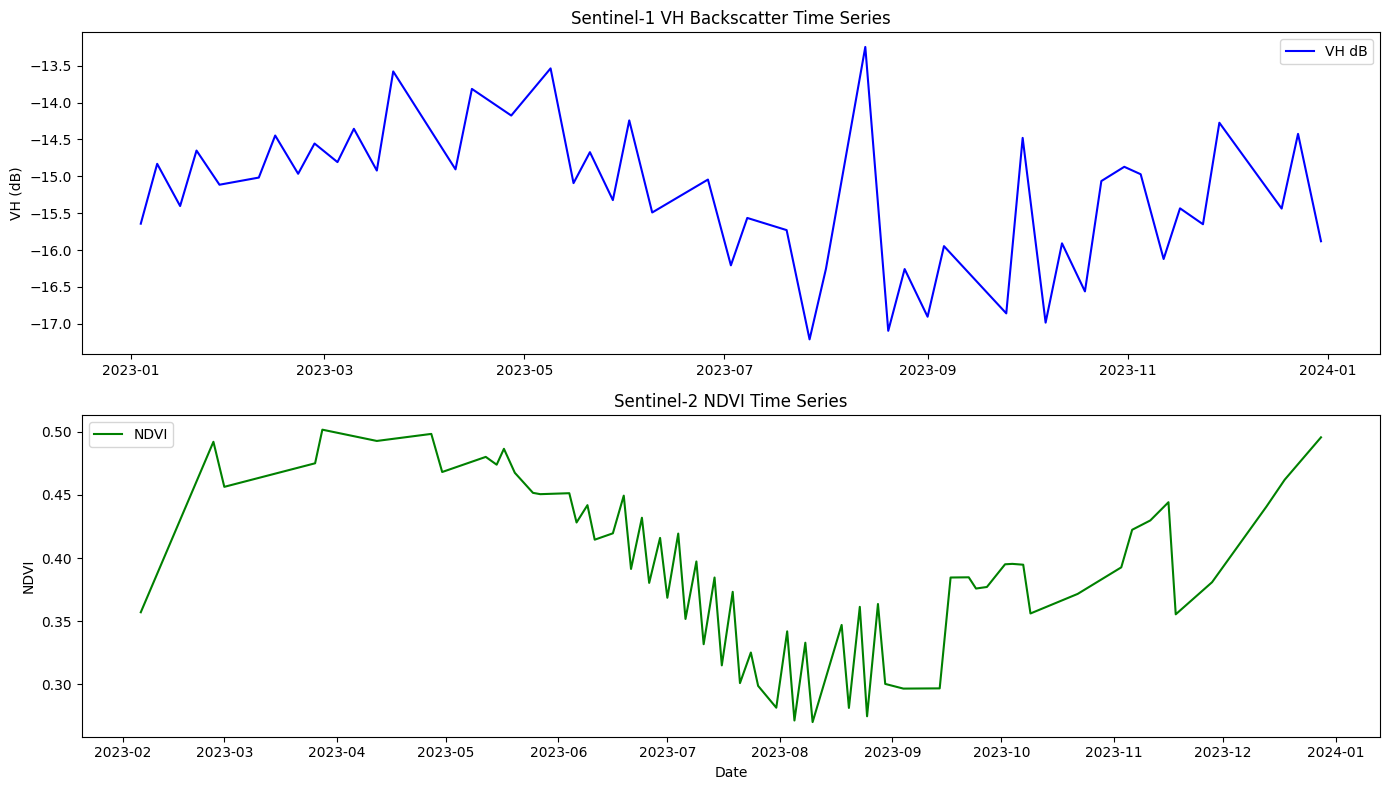

In [11]:
s1_plot = fused_trial.dropna(subset=['vh_db'])
s2_plot = fused_trial.dropna(subset=['ndvi'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(s1_plot['date'], s1_plot['vh_db'], color='blue', label='VH dB')
ax1.set_title('Sentinel-1 VH Backscatter Time Series')
ax1.set_ylabel('VH (dB)')
ax1.legend()


ax2.plot(s2_plot['date'], s2_plot['ndvi'], color='green', label='NDVI')
ax2.set_title('Sentinel-2 NDVI Time Series')
ax2.set_ylabel('NDVI')
ax2.legend()
plt.xlabel('Date')
plt.tight_layout()
plt.show()

Results show the actual seasonal dynamics of the Amazon. The combination of SAR and optical confirms each other — both show stress in the June-September period.

### The Cumulative Sum (CUSUM) control chart is a statistical quality control tool used to detect small, persistent shifts in a process mean by accumulating deviations from a target value.

# CUSUM Mathematical Explanation

### Step 1 — Baseline Mean

Average of the first \(N\) observations.

$$
\mu = \frac{1}{N} \sum_{i=0}^{N-1} VH_i
$$

---

### Step 2 — Baseline Standard Deviation

Measures natural variability in stable forest.  
Small \(\sigma\) means a consistent forest signal.

$$
\sigma = \sqrt{\frac{1}{N-1} \sum_{i=0}^{N-1} (VH_i - \mu)^2}
$$

---

### Step 3 — Slack Parameter

Allows small natural variations without triggering false alarms.  
Only deviations larger than \(k\) accumulate.

$$
k = \frac{\sigma}{2}
$$

---

### Step 4 — Threshold

When cumulative sum crosses \(h\), deforestation is detected.  
Higher \(h\) means fewer false alarms but slower detection.

$$
h = 4\sigma \quad \text{or} \quad h = 5\sigma
$$

---

### Step 5 — Initial CUSUM

Initial cumulative sum starts at zero.

$$
S_0 = 0
$$

---

### Step 6 — Cumulative Sum Calculation

CUSUM accumulates only significant decreases below the baseline.

$$
S_i = \max\left(0,\; S_{i-1} + (\mu - VH_i) - k\right)
$$

Where:

- \((\mu - VH_i)\) = deviation below baseline  
- \(-k\) = slack parameter to ignore small variations  
- \(\max(0,\dots)\) = resets negative cumulative sums to zero  

---

### Step 7 — Change Detection Condition

Deforestation is detected when cumulative sum exceeds threshold.

$$
S_{t^*} > h
$$

---

### Step 8 — First Change Point Time

The first time the cumulative sum crosses the threshold is the detected change point.

$$
t^* = \min\left\{ i > N : S_i > h \right\}
$$

---

### Full Compact CUSUM Equation

$$
S_i = \max\left(0,\; S_{i-1} + (\mu - VH_i) - \frac{\sigma}{2}\right)
$$

CUSUM is done on SAR data. Then look for NDVI on the specific date for the specific pixel. if both drops, confirm deforestation. Different results, false results so reject it.

We run CUSUM only on SAR because radar observation is appr. on evry 12 days, no clouds, no gaps. Perfect for CUSUM. Optical can be irregular observations, gaps due to clouds. CUSUM struggles on missing data. It needs consistent observations to accumulate deviations reliably.


*   SAR provides the alert (cloud-free, sensitive to structure change)
*   Optical provides confirmation (sensitive to vegetation loss)

So we only need VH and NDVI for CUSUM, all other data will be later used in upcoming work of LSTM using Recurrent Neural Network and later a final comparison of results.

The **fused trial** datafrmae can be used for the CUSUM




In [20]:

trail_out = "/content/drive/MyDrive/Deforestation_Project/data/trial"
fused_trial = pd.read_csv(os.path.join(trail_out, 'trial.csv'))
fused_trial['date'] = pd.to_datetime(fused_trial['date'])
print(fused_trial.head(20))
print(len(fused_trial))

         date      vh_db      ndvi
0  2023-01-04 -15.642244       NaN
1  2023-01-09 -14.830198       NaN
2  2023-01-16 -15.402724       NaN
3  2023-01-21 -14.650105       NaN
4  2023-01-28 -15.113631       NaN
5  2023-02-06        NaN  0.356936
6  2023-02-09 -15.016680       NaN
7  2023-02-14 -14.446076       NaN
8  2023-02-21 -14.965112       NaN
9  2023-02-26 -14.554426       NaN
10 2023-02-26        NaN  0.492219
11 2023-03-01        NaN  0.456474
12 2023-03-05 -14.806828       NaN
13 2023-03-10 -14.354810       NaN
14 2023-03-17 -14.921284       NaN
15 2023-03-22 -13.576395       NaN
16 2023-03-26        NaN  0.475161
17 2023-03-28        NaN  0.501835
18 2023-04-10 -14.905118       NaN
19 2023-04-12        NaN  0.492891
114


In [16]:
def CUSUM(dates, vh_values, n_baseline = 10, threshold_factor = 4):
  base_mean = np.mean(vh_values[:n_baseline])    # first 10 values as stable baseline
  base_sigma = np.std(vh_values[:n_baseline])    # baseline standard deviation
  k = base_sigma/2                               # slack parameter k
  h = threshold_factor*base_sigma                # thresold h

  S = [0]
  for i in range(n_baseline, len(vh_values)):
    c_sum = max(0, S[-1] + (base_mean - vh_values[i]) - k)
    S.append(c_sum)

  change_point = None
  for i, s in enumerate(S):
    if s > h:
      change_point = dates[n_baseline + i - len(S)]
      break

  return change_point, S

In [17]:
s1_data = fused_trial.dropna(subset=['vh_db'])
dates = s1_data['date'].tolist()
vh_values = s1_data['vh_db'].tolist()

change_point, cusum_values = CUSUM(dates, vh_values)
print("Change point detected:", change_point)

Change point detected: 2023-09-30 00:00:00


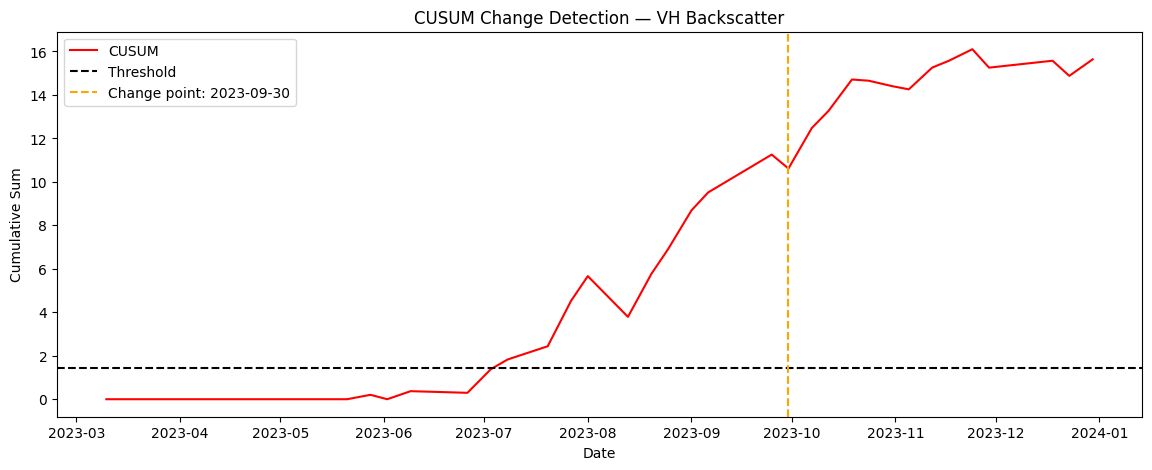

In [18]:
monitoring_dates = dates[10:]

plt.figure(figsize=(14, 5))
plt.plot(monitoring_dates, cusum_values[1:], color='red', label='CUSUM')
plt.axhline(y=4*np.std(vh_values[:10]), color='black',
            linestyle='--', label='Threshold')
plt.axvline(x=change_point, color='orange',
            linestyle='--', label=f'Change point: {change_point.date()}')
plt.title('CUSUM Change Detection — VH Backscatter')
plt.ylabel('Cumulative Sum')
plt.xlabel('Date')
plt.legend()
plt.show()

In [19]:
sept_oct = fused_trial[
    (fused_trial['date'] >= '2023-09-01') &
    (fused_trial['date'] <= '2023-10-31')
]
print(sept_oct)

         date      vh_db      ndvi
77 2023-09-01 -16.904665       NaN
78 2023-09-04        NaN  0.296359
79 2023-09-06 -15.946884       NaN
80 2023-09-14        NaN  0.296541
81 2023-09-17        NaN  0.384517
82 2023-09-22        NaN  0.384686
83 2023-09-24        NaN  0.375771
84 2023-09-25 -16.859180       NaN
85 2023-09-27        NaN  0.376999
86 2023-09-30 -14.478181       NaN
87 2023-10-02        NaN  0.395008
88 2023-10-04        NaN  0.395339
89 2023-10-07 -16.984615       NaN
90 2023-10-07        NaN  0.394674
91 2023-10-09        NaN  0.355981
92 2023-10-12 -15.909003       NaN
93 2023-10-19 -16.560923       NaN
94 2023-10-22        NaN  0.371511
95 2023-10-24 -15.063850       NaN
96 2023-10-31 -14.870529       NaN


# NDVI values around the change point is 0.30-0.40 — significantly lower than the January-May values of 0.47-0.50. This confirms the SAR detection — vegetation is stressed or reduced around the change point.